# DenseCL Representation Evaluation
## Linear Probe, kNN, and t-SNE — Multi-Model Comparison

This notebook evaluates frozen backbone features from one or more DenseCL checkpoints
against an ImageNet baseline. It runs:

1. **Feature extraction** from each model's frozen backbone
2. **Linear probe** (logistic regression) with stratified k-fold CV
3. **kNN evaluation** at multiple k values with cosine distance
4. **t-SNE visualization** of the feature space
5. **Comparative plots** across all models

In [36]:
import numpy as np
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import os
import glob
from utils.DenseCL import DenseCL

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.20.0
GPUs available: 1


In [37]:
# =============================================================================
# CONFIG
# =============================================================================

LABELED_DIR = "data/data_sample_2_pbi"       # subdirectories = class labels
MODELS_DIR = "backbones/dense_1791231432/"          # directory with model checkpoints

IMAGE_SIZE = 224
BATCH_SIZE = 32
N_FOLDS = 5                                 # cross-validation folds
KNN_K_VALUES = [3, 5, 7, 11]               # k values to try
RANDOM_STATE = 42

# Glob pattern to find checkpoints inside MODELS_DIR
# Adjust to match your file naming, e.g. "*.h5", "*.keras", "**/backbone.h5"
CHECKPOINT_GLOB = "cp-0200.keras"

# Set True to include an ImageNet-pretrained baseline
RUN_IMAGENET_BASELINE = True

output_dir = f"{MODELS_DIR}/results"

## 1. Model Loading

In [38]:
def load_backbone(checkpoint_path):
    """
    Load a DenseCL backbone with frozen weights.
    Adjust this to match your saving format.
    """
    full_model = tf.keras.models.load_model(
        checkpoint_path,
        custom_objects={"DenseCL": DenseCL},
        compile=False,
        safe_mode=False,   # required for custom subclassed Models in Keras 3 / TF 2.20
    )

    # Because of the way DenseCL is structured, we need to run a dummy input through it to build the backbone layers
    _ = DenseCL(tf.zeros((2, IMAGE_SIZE, IMAGE_SIZE, 3)), training=True)


    backbone = full_model.backbone   # rename if your attribute is different (e.g. .encoder_q)
    backbone.trainable = False
    return backbone


def load_imagenet_backbone():
    """Load ImageNet-pretrained ResNet50 as baseline."""
    backbone = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        pooling="avg",
    )
    backbone.trainable = False
    return backbone

## 2. Discover Checkpoints

In [39]:
# Find all checkpoints
checkpoint_paths = sorted(glob.glob(os.path.join(MODELS_DIR, CHECKPOINT_GLOB)))
if not checkpoint_paths:
    checkpoint_paths = sorted(glob.glob(
        os.path.join(MODELS_DIR, "**", CHECKPOINT_GLOB), recursive=True
    ))

print(f"Found {len(checkpoint_paths)} checkpoints:")
for i, p in enumerate(checkpoint_paths):
    print(f"  {i+1}. {os.path.relpath(p, MODELS_DIR)}")

# Build model registry
models = {}
for p in checkpoint_paths:
    name = os.path.splitext(os.path.basename(p))[0]
    if name in models:
        name = os.path.basename(os.path.dirname(p)) + "/" + name
    models[name] = p

if RUN_IMAGENET_BASELINE:
    models["ImageNet (baseline)"] = None

print(f"\nModels to evaluate: {list(models.keys())}")

Found 1 checkpoints:
  1. cp-0200.keras

Models to evaluate: ['cp-0200', 'ImageNet (baseline)']


## 3. Feature Extraction

In [40]:
def extract_features(backbone, data_dir):
    """Extract frozen backbone features for all labeled images."""
    dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        label_mode="int",
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    class_names = dataset.class_names
    preprocess = tf.keras.applications.resnet50.preprocess_input

    all_features, all_labels = [], []
    for images, labels in dataset:
        images = preprocess(tf.cast(images, tf.float32))
        features = backbone(images, training=False)
        all_features.append(features.numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_features), np.concatenate(all_labels), class_names

In [41]:
# Extract features for every model
feature_cache = {}

for name, ckpt_path in models.items():
    print(f"\n{'='*60}")
    print(f"  Extracting: {name}")
    print(f"{'='*60}")

    with tf.device('/CPU:0'):
        backbone = load_imagenet_backbone() if ckpt_path is None else load_backbone(ckpt_path)
        features, labels, class_names = extract_features(backbone, LABELED_DIR)

    feature_cache[name] = (features, labels, class_names)

    print(f"  Shape: {features.shape}  |  Classes: {class_names}")
    print(f"  Distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

    del backbone
    tf.keras.backend.clear_session()

print(f"\nCached features for {len(feature_cache)} models.")


  Extracting: cp-0200


ValueError: A total of 4 objects could not be loaded. Example error message for object <Conv2D name=conv2d_9, built=True>:

Layer 'conv2d_9' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Conv2D name=conv2d_9, built=True>, <Dense name=dense_9, built=True>, <Dense name=dense_11, built=True>, <Conv2D name=conv2d_11, built=True>]

In [ ]:
for name, (features, labels, class_names) in feature_cache.items():
    if features.ndim == 4:
        # Apply global average pooling: (250, 7, 7, 2048) -> (250, 2048)
        features = features.mean(axis=(1, 2))
        feature_cache[name] = (features, labels, class_names)
        print(f"  Pooled {name}: {features.shape}")

## 4. Linear Probe (Logistic Regression)

Tests whether class boundaries are linearly separable in each model's feature space.
Uses stratified k-fold CV since we only have ~250 labeled images.

In [ ]:
def linear_probe(features, labels, n_folds=N_FOLDS, C=1.0):
    """Stratified k-fold logistic regression on frozen features."""
    scaler = StandardScaler()
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    fold_accs = []
    all_preds = np.zeros_like(labels)

    for train_idx, val_idx in skf.split(features, labels):
        X_train = scaler.fit_transform(features[train_idx])
        X_val = scaler.transform(features[val_idx])

        clf = LogisticRegression(
            max_iter=1000, 
            C=C, 
            solver="lbfgs",
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )
        clf.fit(X_train, labels[train_idx])
        preds = clf.predict(X_val)
        fold_accs.append(accuracy_score(labels[val_idx], preds))
        all_preds[val_idx] = preds

    return np.mean(fold_accs), np.std(fold_accs), fold_accs, all_preds

# Run
linear_results = {}
for name, (features, labels, _) in feature_cache.items():
    mean, std, folds, preds = linear_probe(features, labels)
    linear_results[name] = (mean, std, folds, preds)
    print(f"{name:>30s}:  {mean:.4f} \u00b1 {std:.4f}")

           ImageNet (baseline):  0.7600 ± 0.0540


## 5. kNN Evaluation

Training-free evaluation using cosine distance. Tests local neighborhood
quality — are an image's nearest neighbors the same class?

In [ ]:
def knn_evaluate(features, labels, k_values=KNN_K_VALUES, n_folds=N_FOLDS):
    """Stratified k-fold kNN at multiple k values."""
    scaler = StandardScaler()
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    results = {}

    for k in k_values:
        fold_accs = []
        all_preds = np.zeros_like(labels)

        for train_idx, val_idx in skf.split(features, labels):
            X_train = scaler.fit_transform(features[train_idx])
            X_val = scaler.transform(features[val_idx])

            knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", weights="distance")
            knn.fit(X_train, labels[train_idx])
            preds = knn.predict(X_val)
            fold_accs.append(accuracy_score(labels[val_idx], preds))
            all_preds[val_idx] = preds

        results[k] = (np.mean(fold_accs), np.std(fold_accs), fold_accs, all_preds)
    return results

# Run
knn_results = {}
for name, (features, labels, _) in feature_cache.items():
    knn_results[name] = knn_evaluate(features, labels)
    best_k = max(knn_results[name], key=lambda k: knn_results[name][k][0])
    row = "  ".join([f"k={k}: {r[0]:.3f}" for k, r in knn_results[name].items()])
    print(f"{name:>30s}:  {row}")

           ImageNet (baseline):  k=3: 0.802  k=5: 0.812  k=7: 0.806  k=11: 0.804


## 6. Classification Reports (Linear Probe)

In [ ]:
for name in models:
    _, labels, class_names = feature_cache[name]
    preds = linear_results[name][3]
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(labels, preds, target_names=class_names))


  ImageNet (baseline)
              precision    recall  f1-score   support

     class_0       0.84      0.87      0.85       400
     class_1       0.38      0.33      0.35       100

    accuracy                           0.76       500
   macro avg       0.61      0.60      0.60       500
weighted avg       0.75      0.76      0.75       500



## 7. Visualizations

### Accuracy Comparison Bar Chart

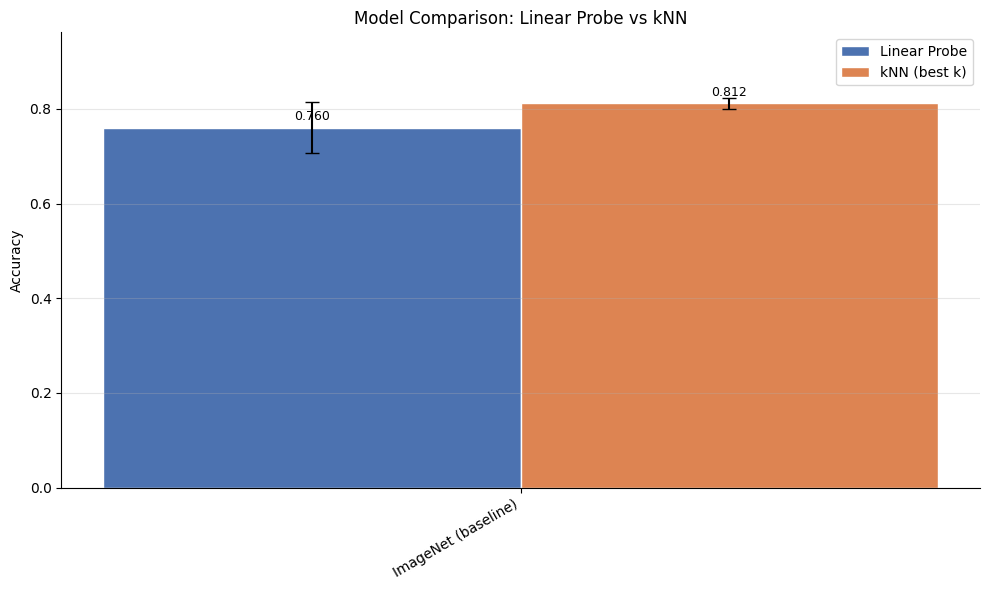

In [ ]:
model_names = list(models.keys())
n = len(model_names)

lp_accs = [linear_results[m][0] for m in model_names]
lp_stds = [linear_results[m][1] for m in model_names]
knn_accs, knn_stds = [], []
for m in model_names:
    bk = max(knn_results[m], key=lambda k: knn_results[m][k][0])
    knn_accs.append(knn_results[m][bk][0])
    knn_stds.append(knn_results[m][bk][1])

x = np.arange(n)
w = 0.35

fig, ax = plt.subplots(figsize=(max(10, n * 2.5), 6))
b1 = ax.bar(x - w/2, lp_accs, w, yerr=lp_stds, label="Linear Probe",
            capsize=5, color="#4C72B0", edgecolor="white")
b2 = ax.bar(x + w/2, knn_accs, w, yerr=knn_stds, label="kNN (best k)",
            capsize=5, color="#DD8452", edgecolor="white")

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison: Linear Probe vs kNN")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, min(1.0, max(max(lp_accs), max(knn_accs)) + 0.15))
ax.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### kNN Accuracy Across k Values

Stable lines = tight, well-separated clusters. Sharp drops at higher k = fuzzy boundaries.

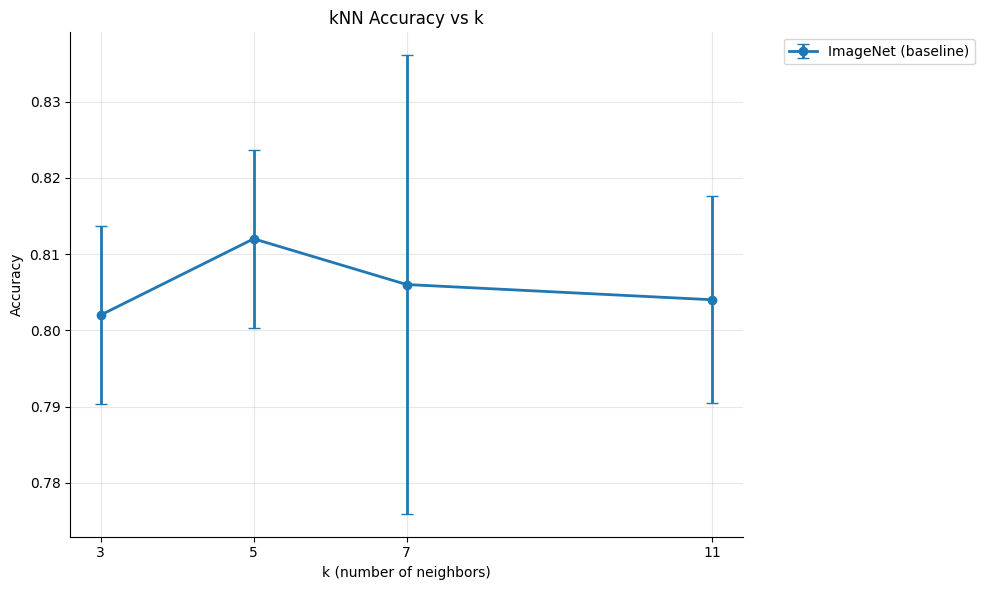

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = cm.tab10(np.linspace(0, 1, len(models)))

for (name, res), color in zip(knn_results.items(), colors):
    ks = sorted(res.keys())
    accs = [res[k][0] for k in ks]
    stds = [res[k][1] for k in ks]
    ax.errorbar(ks, accs, yerr=stds, marker="o", label=name, capsize=4, linewidth=2, color=color)

ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Accuracy")
ax.set_title("kNN Accuracy vs k")
ax.set_xticks(KNN_K_VALUES)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/knn_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion Matrices (Linear Probe)

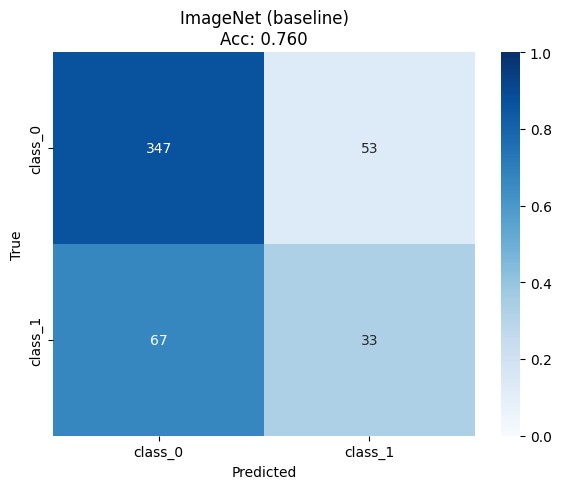

In [ ]:
n_m = len(models)
cols = min(3, n_m)
rows_p = (n_m + cols - 1) // cols

fig, axes = plt.subplots(rows_p, cols, figsize=(6 * cols, 5 * rows_p))
if n_m == 1:
    axes = np.array([axes])
axes = axes.flatten()

_, labels, class_names = list(feature_cache.values())[0]

for idx, name in enumerate(models):
    ax = axes[idx]
    preds = linear_results[name][3]
    cm_raw = confusion_matrix(labels, preds)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm_raw, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{name}\nAcc: {accuracy_score(labels, preds):.3f}")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

for idx in range(n_m, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### t-SNE Feature Space Visualization

Running t-SNE for ImageNet (baseline)...


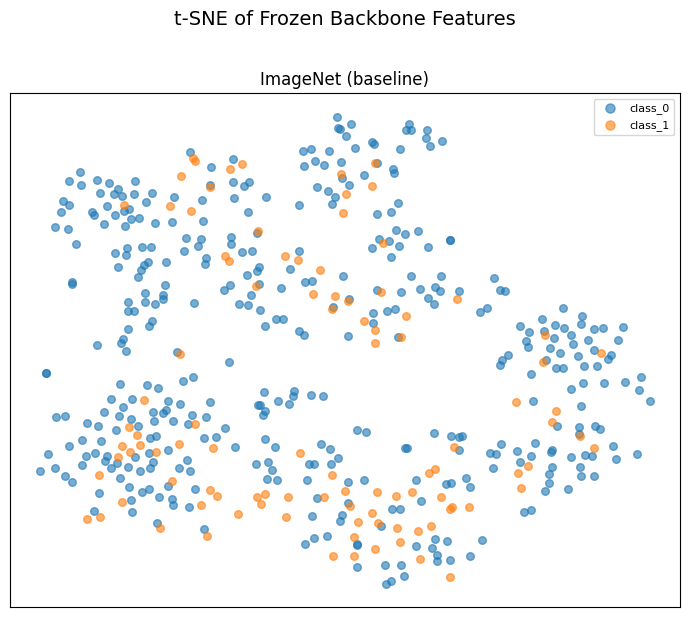

In [ ]:
n_m = len(models)
cols = min(3, n_m)
rows_p = (n_m + cols - 1) // cols

fig, axes = plt.subplots(rows_p, cols, figsize=(7 * cols, 6 * rows_p))
if n_m == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, name in enumerate(models):
    ax = axes[idx]
    features, labels, class_names = feature_cache[name]

    print(f"Running t-SNE for {name}...")
    tsne = TSNE(n_components=2, perplexity=min(30, len(labels) // 4),
                random_state=RANDOM_STATE)
    feats_2d = tsne.fit_transform(StandardScaler().fit_transform(features))

    for i, cname in enumerate(class_names):
        mask = labels == i
        ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                   label=cname, alpha=0.6, s=30)

    ax.set_title(name)
    ax.legend(fontsize=8, markerscale=1.2)
    ax.set_xticks([])
    ax.set_yticks([])

for idx in range(n_m, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("t-SNE of Frozen Backbone Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Per-Class Accuracy Heatmap

Shows which aurora types each model handles well or poorly.

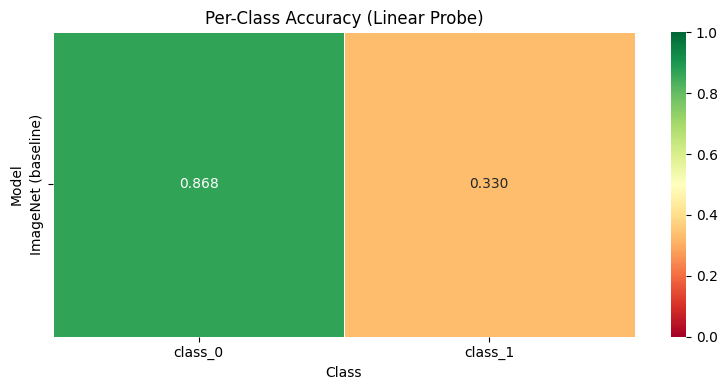

In [ ]:
_, labels, class_names = list(feature_cache.values())[0]
per_class = {}
for name in models:
    preds = linear_results[name][3]
    per_class[name] = [accuracy_score(labels[labels == i], preds[labels == i])
                       for i in range(len(class_names))]

df_pc = pd.DataFrame(per_class, index=class_names).T

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 1.5), max(4, len(models) * 0.8)))
sns.heatmap(df_pc, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Per-Class Accuracy (Linear Probe)")
ax.set_ylabel("Model")
ax.set_xlabel("Class")
plt.tight_layout()
plt.savefig(f"{output_dir}/per_class_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Cross-Validation Fold Variance

With only ~250 images, fold variance tells you how stable the results are.

/tmp/ipykernel_281400/1022117265.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


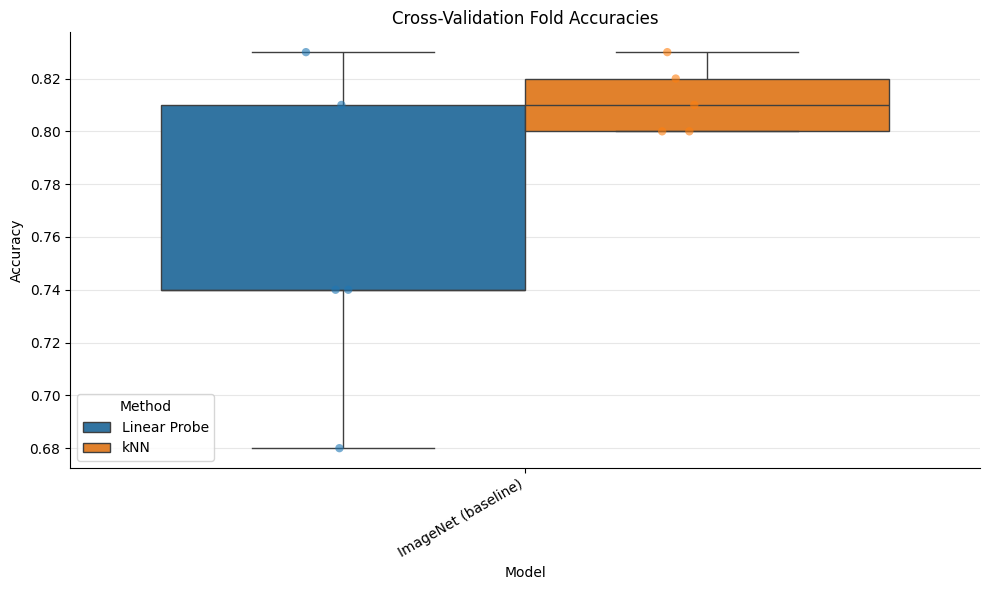

In [ ]:
fold_data = []
for name in models:
    for fa in linear_results[name][2]:
        fold_data.append({"Model": name, "Accuracy": fa, "Method": "Linear Probe"})
    bk = max(knn_results[name], key=lambda k: knn_results[name][k][0])
    for fa in knn_results[name][bk][2]:
        fold_data.append({"Model": name, "Accuracy": fa, "Method": "kNN"})

df_folds = pd.DataFrame(fold_data)

fig, ax = plt.subplots(figsize=(max(10, len(models) * 3), 6))
sns.boxplot(data=df_folds, x="Model", y="Accuracy", hue="Method", ax=ax)
sns.stripplot(data=df_folds, x="Model", y="Accuracy", hue="Method",
              dodge=True, alpha=0.6, size=6, ax=ax, legend=False)
ax.set_title("Cross-Validation Fold Accuracies")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/fold_variance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary

In [ ]:
summary_rows = []
for name in models:
    lp_mean, lp_std = linear_results[name][0], linear_results[name][1]
    bk = max(knn_results[name], key=lambda k: knn_results[name][k][0])
    knn_mean, knn_std = knn_results[name][bk][0], knn_results[name][bk][1]
    summary_rows.append({
        "Model": name,
        "Linear Probe": f"{lp_mean:.4f} \u00b1 {lp_std:.4f}",
        "Best kNN": f"{knn_mean:.4f} \u00b1 {knn_std:.4f}",
        "Best k": bk,
    })

df_summary = pd.DataFrame(summary_rows).set_index("Model")

# Compute deltas vs ImageNet if available
if "ImageNet (baseline)" in linear_results:
    base_lp = linear_results["ImageNet (baseline)"][0]
    deltas = []
    for name in models:
        if name == "ImageNet (baseline)":
            deltas.append("\u2014")
        else:
            d = linear_results[name][0] - base_lp
            deltas.append(f"{'+' if d >= 0 else ''}{d*100:.1f}pp")
    df_summary["vs ImageNet (LP)"] = deltas

print(df_summary.to_string())

                        Linear Probe         Best kNN  Best k vs ImageNet (LP)
Model                                                                         
ImageNet (baseline)  0.7600 ± 0.0540  0.8120 ± 0.0117       5                —


In [ ]:
# Save all results to CSV
all_rows = []
for name in models:
    lp_mean, lp_std = linear_results[name][0], linear_results[name][1]
    for k, (km, ks, _, _) in knn_results[name].items():
        all_rows.append({
            "model": name, "linear_probe_acc": lp_mean, "linear_probe_std": lp_std,
            "knn_k": k, "knn_acc": km, "knn_std": ks,
        })

pd.DataFrame(all_rows).to_csv(f"{output_dir}/evaluation_results.csv", index=False)
print(f"Saved to {output_dir}/evaluation_results.csv")

Saved to trained_backbones/backbone_test1/results/evaluation_results.csv
